In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

In [2]:
df = pd.read_csv("Better_Dataset.csv")

df.head()

,date,temperature,humidity,verdict
0,2024-03-01 00:00:00,24.912950,36.451926,1
1,2024-03-01 04:00:00,31.259358,50.668960,0
2,2024-03-01 08:00:00,29.988245,55.987899,0
3,2024-03-01 12:00:00,35.314738,56.160208,0
4,2024-03-01 16:00:00,26.163837,48.280121,1


In [3]:
df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2311 entries, 0 to 2310
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2311 non-null   datetime64[ns]
 1   temperature  2311 non-null   float64       
 2   humidity     2311 non-null   float64       
 3   verdict      2311 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 72.3 KB


In [5]:
print("Rows and Columns:", df.shape)

df.describe()

Rows and Columns: (2311, 4)


,date,temperature,humidity,verdict
count,2311,2311.000000,2311.000000,2311.000000
mean,2024-09-09 12:00:00,27.003090,53.069079,0.302034
min,2024-03-01 00:00:00,9.672369,0.000000,0.000000
25%,2024-06-05 06:00:00,21.586704,43.870155,0.000000
50%,2024-09-09 12:00:00,25.985870,53.944031,0.000000
75%,2024-12-14 18:00:00,31.644917,63.679985,1.000000
max,2025-03-21 00:00:00,58.443347,95.429325,1.000000
std,NaN,7.558388,14.306975,0.459239


In [6]:
df["Threshold_Anomaly"] = (
    (df["temperature"] > 40) |
    (df["temperature"] < 15)
)

df["Threshold_Anomaly"].value_counts()

,count
Threshold_Anomaly,
False,2105
True,206


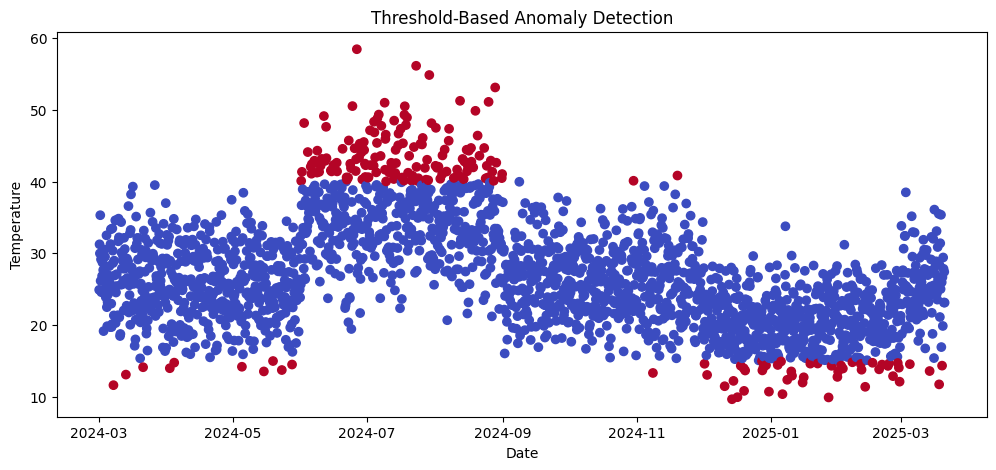

In [7]:
plt.figure(figsize=(12,5))

plt.scatter(
    df["date"],
    df["temperature"],
    c=df["Threshold_Anomaly"],
    cmap="coolwarm"
)

plt.title("Threshold-Based Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Temperature")

plt.show()

In [8]:
features = df[["temperature", "humidity"]]

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

df["IsolationForest"] = model.fit_predict(features)

df["IsolationForest"] = df["IsolationForest"].map({
    1: "Normal",
    -1: "Anomaly"
})

df["IsolationForest"].value_counts()

,count
IsolationForest,
Normal,2195
Anomaly,116


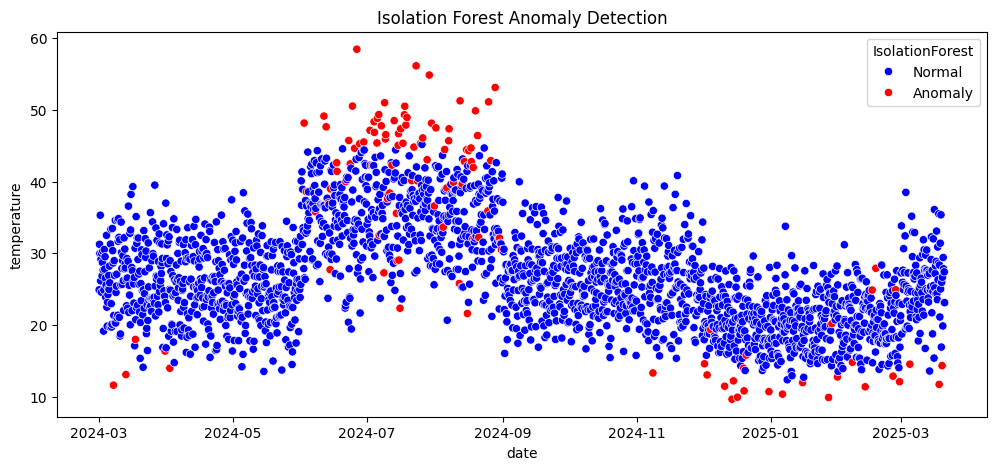

In [9]:
plt.figure(figsize=(12,5))

sns.scatterplot(
    data=df,
    x="date",
    y="temperature",
    hue="IsolationForest",
    palette={
        "Normal":"blue",
        "Anomaly":"red"
    }
)

plt.title("Isolation Forest Anomaly Detection")

plt.show()

In [10]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

df["LOF"] = lof.fit_predict(features)

df["LOF"] = df["LOF"].map({
    1: "Normal",
    -1: "Anomaly"
})

df["LOF"].value_counts()

,count
LOF,
Normal,2195
Anomaly,116


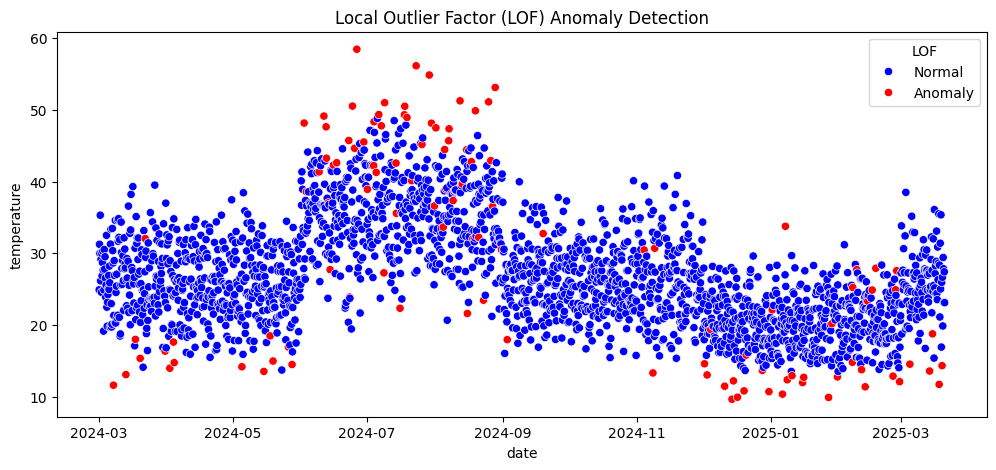

In [11]:
plt.figure(figsize=(12,5))

sns.scatterplot(
    data=df,
    x="date",
    y="temperature",
    hue="LOF",
    palette={
        "Normal":"blue",
        "Anomaly":"red"
    }
)

plt.title("Local Outlier Factor (LOF) Anomaly Detection")

plt.show()

In [12]:
print("Threshold-Based Detection")
print(df["Threshold_Anomaly"].value_counts())

print("\nIsolation Forest")
print(df["IsolationForest"].value_counts())

print("\nLocal Outlier Factor")
print(df["LOF"].value_counts())

Threshold-Based Detection
Threshold_Anomaly
False    2105
True      206
Name: count, dtype: int64

Isolation Forest
IsolationForest
Normal     2195
Anomaly     116
Name: count, dtype: int64

Local Outlier Factor
LOF
Normal     2195
Anomaly     116
Name: count, dtype: int64
